In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt 

[0.         0.12693304 0.25386607 0.38079911 0.50773215 0.63466518
 0.76159822 0.88853126 1.01546429 1.14239733]
[0.         0.25645654 0.51291309 0.76936963 1.02582617 1.28228272
 1.53873926 1.7951958  2.05165235 2.30810889]


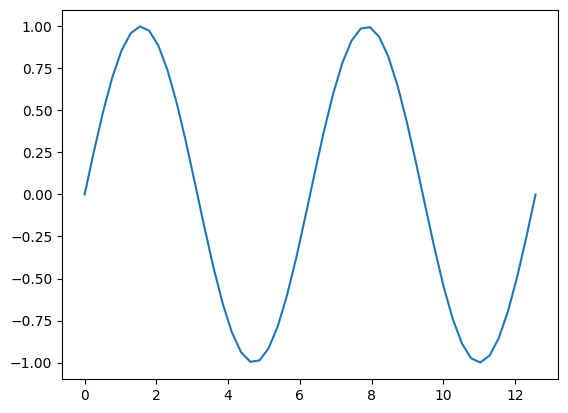

In [2]:
x_train= np.linspace(0,4*np.pi, 100)
y_train= torch.from_numpy(np.sin(x_train))

x_test= np.linspace(0,4*np.pi, 50)
y_test= torch.from_numpy(np.sin(x_test))


print(x_train[:10])
print(x_test[:10])

plt.subplot(1,1,1)
plt.plot(x_test,y_test)

### Question:
we do generate test data with diffrent points to avoid overfit the network
        

In [32]:
torch.manual_seed(42)
# parameters setup
# layer1 params
w_l1 = torch.rand((1,64)) 
b_l1 = torch.rand((64,)) 
# layer2 params
w_l2 = torch.rand((64,64)) 
b_l2 = torch.rand((64,))  

# layer3 params
w_l3 = torch.rand((64,)) 
b_l3 = torch.rand(()) 

params = [w_l1, b_l1, w_l2, b_l2,w_l3,b_l3]
for param in params:
    param.requires_grad = True

# Layer 1
# w_l1 = torch.rand((1, 64))
# b_l1 = torch.rand((64,))  # ← Changed from (1, 64) to (64,)

# # Layer 2
# w_l2 = torch.rand((64, 64))
# b_l2 = torch.rand((64,))  # ← Changed from (1, 64) to (64,)

# # Layer 3
# w_l3 = torch.rand((64,))
# b_l3 = torch.rand(())  # ← Changed from (1,) to scalar

# params = [w_l1, b_l1, w_l2, b_l2, w_l3, b_l3]
# for param in params:
#     param.requires_grad = True

In [28]:
b_l1 = torch.rand((64,))
print(b_l1.shape)
b_l1 = torch.rand((64))
print(b_l1.shape)

torch.Size([64])
torch.Size([64])


In [11]:
# def forward(input):
#     input  = torch.tensor([input]) 
#     result = w_l1.reshape(64,1)@input + b_l1
#     result = torch.relu(result)
#     result = w_l2@torch.squeeze(result) + b_l2
#     result = torch.relu(result)
#     result = w_l3@result.T + b_l3
#     return result
def forward(input):
    x = torch.tensor([[input]])  # Shape: (1, 1)
    
    # Layer 1: (1, 1) @ (1, 64) → (1, 64)
    x = torch.relu(x @ w_l1 + b_l1)
    
    # Layer 2: (1, 64) @ (64, 64) → (1, 64)
    x = torch.relu(x @ w_l2 + b_l2)
    
    # Layer 3: (1, 64) @ (64,) → (1,)
    x = x @ w_l3 + b_l3
    
    return x.squeeze()

In [ ]:
# training loop
epochs = 6000
pred = torch.zeros(len(y_train))
optim = torch.optim.Adam(params,lr=0.005)
epochs_his =[]
loss_his   =[]
for epoch in range(epochs):
    optim.zero_grad()
    # pred = torch.tensor([forward(float(x)) for x in x_test])
    pred = torch.stack([forward(float(x)) for x in x_train])

    loss = torch.mean((pred-y_train)**2)
    
    loss.backward()
    
    optim.step()

    # print("epoch {} || loss {} ".format(epoch, loss))
    # with torch.no_grad():
    epochs_his.append(epoch)
    loss_his.append(loss.item())
        
plt.subplot()
plt.plot(epochs_his,loss_his)
    

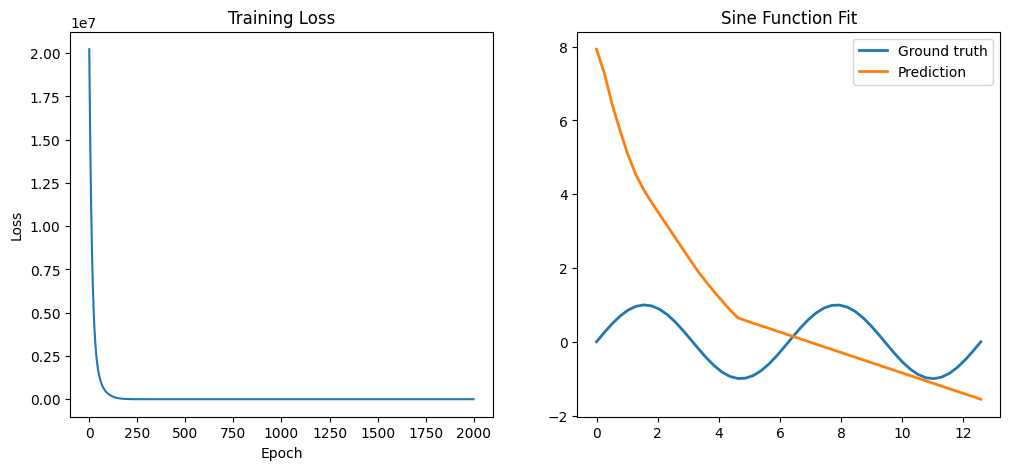

In [34]:
# with torch.no_grad():
#     y_pred_test =  torch.tensor([forward(float(x)) for x in x_test])
#     plt.subplot()
#     plt.plot(x_test,y_test)
#     plt.plot(x_test,y_pred_test.numpy())
#     print(y_test)
#     print(y_pred_test)

with torch.no_grad():
    y_pred_test = torch.stack([forward(float(x)) for x in x_test])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(loss_his)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(x_test, y_test.numpy(), label='Ground truth', linewidth=2)
    plt.plot(x_test, y_pred_test.numpy(), label='Prediction', linewidth=2)
    plt.legend()
    plt.title('Sine Function Fit')
    plt.show()

In [ ]:
def forward(input):
    input  = torch.tensor([input]) 
    result = w_l1.reshape(64,1)@input + b_l1
    result = torch.relu(result)
    print("result after 1",result.shape)
    print("result after 1",result.T.shape)
    print("result after 1",torch.squeeze(result).shape)
    result = w_l2@result.T + b_l2
    print("result after 2",result.shape)
    print("result after 2",torch.squeeze(result).shape)
    result = torch.relu(result)
    print("w_l2",w_l2.shape)
    
    result = w_l3@result.T + b_l3
    print("result after 3",result.shape)
    print(w_l3.shape)
    print(b_l3.shape)
    
    return result
print(forward(np.pi))